In [16]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import zipfile

In [ ]:
with zipfile.ZipFile('../data/archive.zip', 'r') as f:
    print(f'The archive contains: \n{f.namelist()}')
    f.extractall(path='../data/')

In [17]:
dataset = pd.read_csv('../adhdata.csv')

In [20]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2166383 entries, 0 to 2166382
Data columns (total 21 columns):
 #   Column  Dtype  
---  ------  -----  
 0   Fp1     float64
 1   Fp2     float64
 2   F3      float64
 3   F4      float64
 4   C3      float64
 5   C4      float64
 6   P3      float64
 7   P4      float64
 8   O1      float64
 9   O2      float64
 10  F7      float64
 11  F8      float64
 12  T7      float64
 13  T8      float64
 14  P7      float64
 15  P8      float64
 16  Fz      float64
 17  Cz      float64
 18  Pz      float64
 19  Class   object 
 20  ID      object 
dtypes: float64(19), object(2)
memory usage: 347.1+ MB


In [21]:
dataset[12:17]

,Fp1,Fp2,F3,F4,C3,C4,P3,P4,O1,O2,...,F8,T7,T8,P7,P8,Fz,Cz,Pz,Class,ID
12,930.0,1001.0,236.0,437.0,16.0,384.0,-278.0,163.0,52.0,200.0,...,384.0,236.0,420.0,-20.0,273.0,402.0,367.0,15.0,ADHD,v10p
13,1106.0,1001.0,494.0,543.0,347.0,531.0,89.0,310.0,52.0,163.0,...,420.0,420.0,457.0,163.0,273.0,473.0,402.0,191.0,ADHD,v10p
14,860.0,684.0,273.0,297.0,163.0,310.0,-57.0,89.0,310.0,236.0,...,273.0,310.0,310.0,52.0,163.0,332.0,226.0,-19.0,ADHD,v10p
15,789.0,719.0,273.0,367.0,163.0,420.0,-20.0,273.0,126.0,273.0,...,236.0,347.0,420.0,163.0,273.0,332.0,367.0,156.0,ADHD,v10p
16,860.0,789.0,310.0,332.0,200.0,347.0,126.0,200.0,163.0,236.0,...,273.0,310.0,310.0,126.0,163.0,332.0,191.0,15.0,ADHD,v10p


In [22]:
shuffled_data = dataset.sample(frac=1, random_state=37).reset_index(drop=True)

In [23]:
shuffled_data[12:17]

,Fp1,Fp2,F3,F4,C3,C4,P3,P4,O1,O2,...,F8,T7,T8,P7,P8,Fz,Cz,Pz,Class,ID
12,85.0,15.0,-20.0,-19.0,-20.0,273.0,16.0,-131.0,-57.0,-241.0,...,52.0,200.0,-57.0,-20.0,-57.0,-90.0,-231.0,-231.0,ADHD,v15p
13,332.0,367.0,347.0,402.0,200.0,236.0,-57.0,126.0,310.0,310.0,...,384.0,-903.0,-57.0,16.0,126.0,332.0,-19.0,15.0,Control,v49p
14,-19.0,156.0,-20.0,226.0,-20.0,200.0,-241.0,52.0,-167.0,-57.0,...,163.0,-20.0,163.0,-94.0,163.0,50.0,121.0,-195.0,Control,v149
15,-90.0,50.0,16.0,15.0,16.0,16.0,89.0,16.0,89.0,52.0,...,89.0,52.0,52.0,16.0,89.0,-19.0,-55.0,121.0,ADHD,v263
16,50.0,156.0,89.0,156.0,163.0,236.0,236.0,126.0,347.0,163.0,...,126.0,89.0,163.0,126.0,236.0,85.0,191.0,156.0,ADHD,v198


In [25]:
shuffled_data.dtypes

Fp1      float64
Fp2      float64
F3       float64
F4       float64
C3       float64
C4       float64
P3       float64
P4       float64
O1       float64
O2       float64
F7       float64
F8       float64
T7       float64
T8       float64
P7       float64
P8       float64
Fz       float64
Cz       float64
Pz       float64
Class     object
ID        object
dtype: object

In [26]:
shuffled_data.shape

(2166383, 21)

In [27]:
shuffled_data['Class'].value_counts()

Class
ADHD       1207069
Control     959314
Name: count, dtype: int64

In [28]:
shuffled_data['Class'].value_counts(normalize=True) * 100

Class
ADHD       55.718172
Control    44.281828
Name: proportion, dtype: float64

In [29]:
shuffled_data['ID'].nunique()

121

In [31]:
rows_per_participant = shuffled_data.groupby('ID').size()
print(rows_per_participant.head())
print(rows_per_participant.min())
print(rows_per_participant.max())

ID
v107    19794
v108    19026
v109    16044
v10p    14304
v110    16549
dtype: int64
7983
43252


In [34]:
# Get rows per participant with their class label
info_participant = shuffled_data.groupby(['ID', 'Class']).size().reset_index(name='row_count')
# Convert rows to seconds of recording
info_participant['seconds'] = (info_participant['row_count']/128).round(1)
 # sort by row count to see extremes
print(info_participant.sort_values('row_count', ascending=False).head())
print(info_participant.sort_values('row_count', ascending=True).head())

      ID Class  row_count  seconds
30  v15p  ADHD      43252    337.9
57  v244  ADHD      39030    304.9
46  v20p  ADHD      35328    276.0
54  v234  ADHD      34191    267.1
97   v3p  ADHD      33570    262.3
       ID    Class  row_count  seconds
109  v51p  Control       7983     62.4
94   v37p     ADHD       9286     72.5
104  v46p  Control       9823     76.7
56   v238     ADHD       9852     77.0
62   v25p     ADHD       9894     77.3


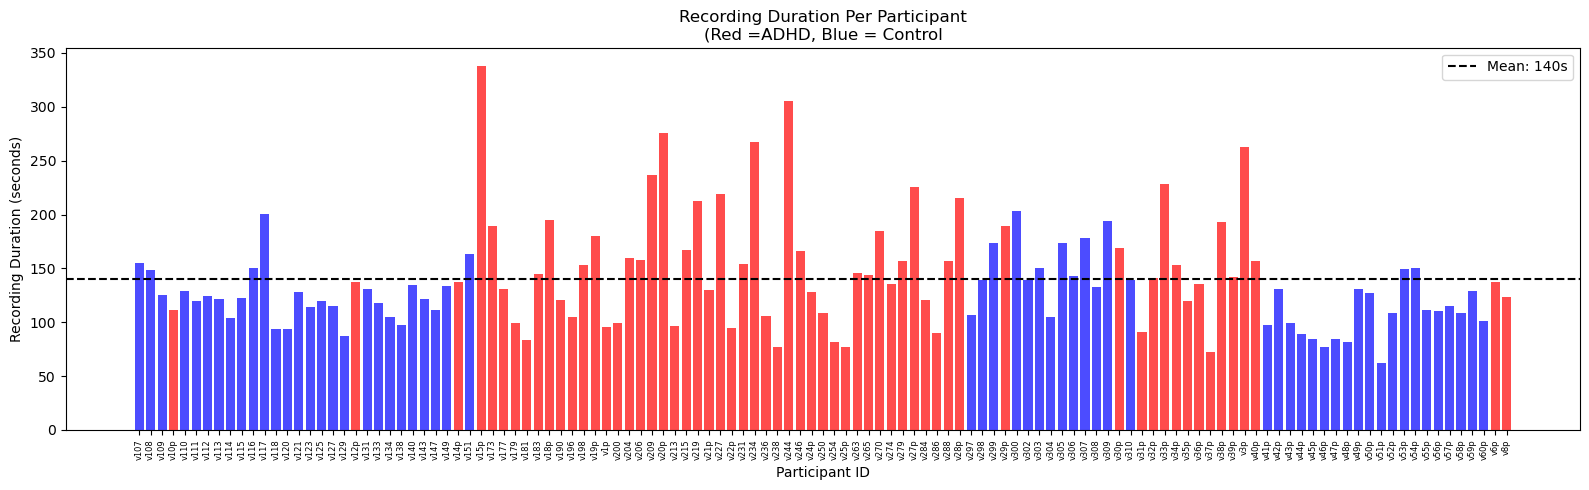

In [35]:
plt.figure(figsize=(16,5))
colors = info_participant['Class'].map({'ADHD': 'red', 'Control': 'blue'})
plt.bar(info_participant['ID'], info_participant['seconds'], color=colors, alpha=0.7)
plt.axhline(y=info_participant['seconds'].mean(),
           color='black', linestyle='--', linewidth=1.5,
           label=f"Mean: {info_participant['seconds'].mean():.0f}s")
plt.xticks(rotation=90, fontsize=6)
plt.xlabel('Participant ID')
plt.ylabel('Recording Duration (seconds)')
plt.title('Recording Duration Per Participant\n(Red =ADHD, Blue = Control')
plt.legend()
plt.tight_layout()
plt.show()

## Recording Duration Analysis

- Total participants: 121 (61 ADHD, 60 Control)
- Total rows: 2,166,383 at 128 Hz sampling rate
- Each row represents one raw time point (1/128th of a second)
- Mean recording duration: 140 seconds per participant

**Class imbalance at row level:**
- ADHD: 1,207,069 rows (55.7%)
- Control: 959,314 rows (44.3%)

**Recording duration range:**
- Shortest: 62 seconds (Control participant v51p)
- Longest: 338 seconds (ADHD participant v15p)
- Fivefold difference between shortest and longest

The 5 longest recordings all belong to ADHD participants, consistent
with slower processing speed and longer response times documented
in ADHD literature. This confirms the dataset reflects genuine
ADHD behavioural characteristics beyond just EEG signal differences.

Threshold set at 70% because below this point the participant retains less than 30 seconds of usable clean data, which is insufficient for reliable epoch-based feature extraction.

In [38]:
missing_values = shuffled_data.isnull().sum()
print(f'Missing values per column is: {missing_values}')

percentage_missing = (shuffled_data.isnull().mean() * 100).round(4)
print(f'Percentage of missing columns is: {percentage_missing}')

print(f'Total missing values is: {shuffled_data.isnull().sum().sum()}')

Missing values per column is: Fp1      0
Fp2      0
F3       0
F4       0
C3       0
C4       0
P3       0
P4       0
O1       0
O2       0
F7       0
F8       0
T7       0
T8       0
P7       0
P8       0
Fz       0
Cz       0
Pz       0
Class    0
ID       0
dtype: int64
Percentage of missing columns is: Fp1      0.0
Fp2      0.0
F3       0.0
F4       0.0
C3       0.0
C4       0.0
P3       0.0
P4       0.0
O1       0.0
O2       0.0
F7       0.0
F8       0.0
T7       0.0
T8       0.0
P7       0.0
P8       0.0
Fz       0.0
Cz       0.0
Pz       0.0
Class    0.0
ID       0.0
dtype: float64
Total missing values is: 0


In [40]:
# check voltage ranges per column
eeg_channels = ['Fp1','Fp2','F3','F4','C3','C4','P3','P4',
                'O1','O2','F7','F8','T7','T8','P7','P8',
                'Fz','Cz','Pz']

print(f'Statistical summary of all EEG channels is {shuffled_data[eeg_channels].describe().round(2)}')

Statistical summary of all EEG channels is               Fp1         Fp2          F3          F4          C3          C4  \
count  2166383.00  2166383.00  2166383.00  2166383.00  2166383.00  2166383.00   
mean       136.09      136.16      142.21      136.10      142.27      142.20   
std        275.55      275.51      220.65      213.39      223.49      210.72   
min      -3786.00   -13224.00    -3921.00   -13237.00    -3921.00    -3921.00   
25%         15.00       15.00       52.00       15.00       52.00       52.00   
50%        121.00      121.00      126.00      121.00      126.00      126.00   
75%        261.00      226.00      236.00      226.00      236.00      236.00   
max      13813.00     4802.00     5020.00     4802.00     5430.00     5020.00   

               P3          P4          O1         O2          F7          F8  \
count  2166383.00  2166383.00  2166383.00  2166383.0  2166383.00  2166383.00   
mean       142.28      141.96      141.98      141.6      142.06   

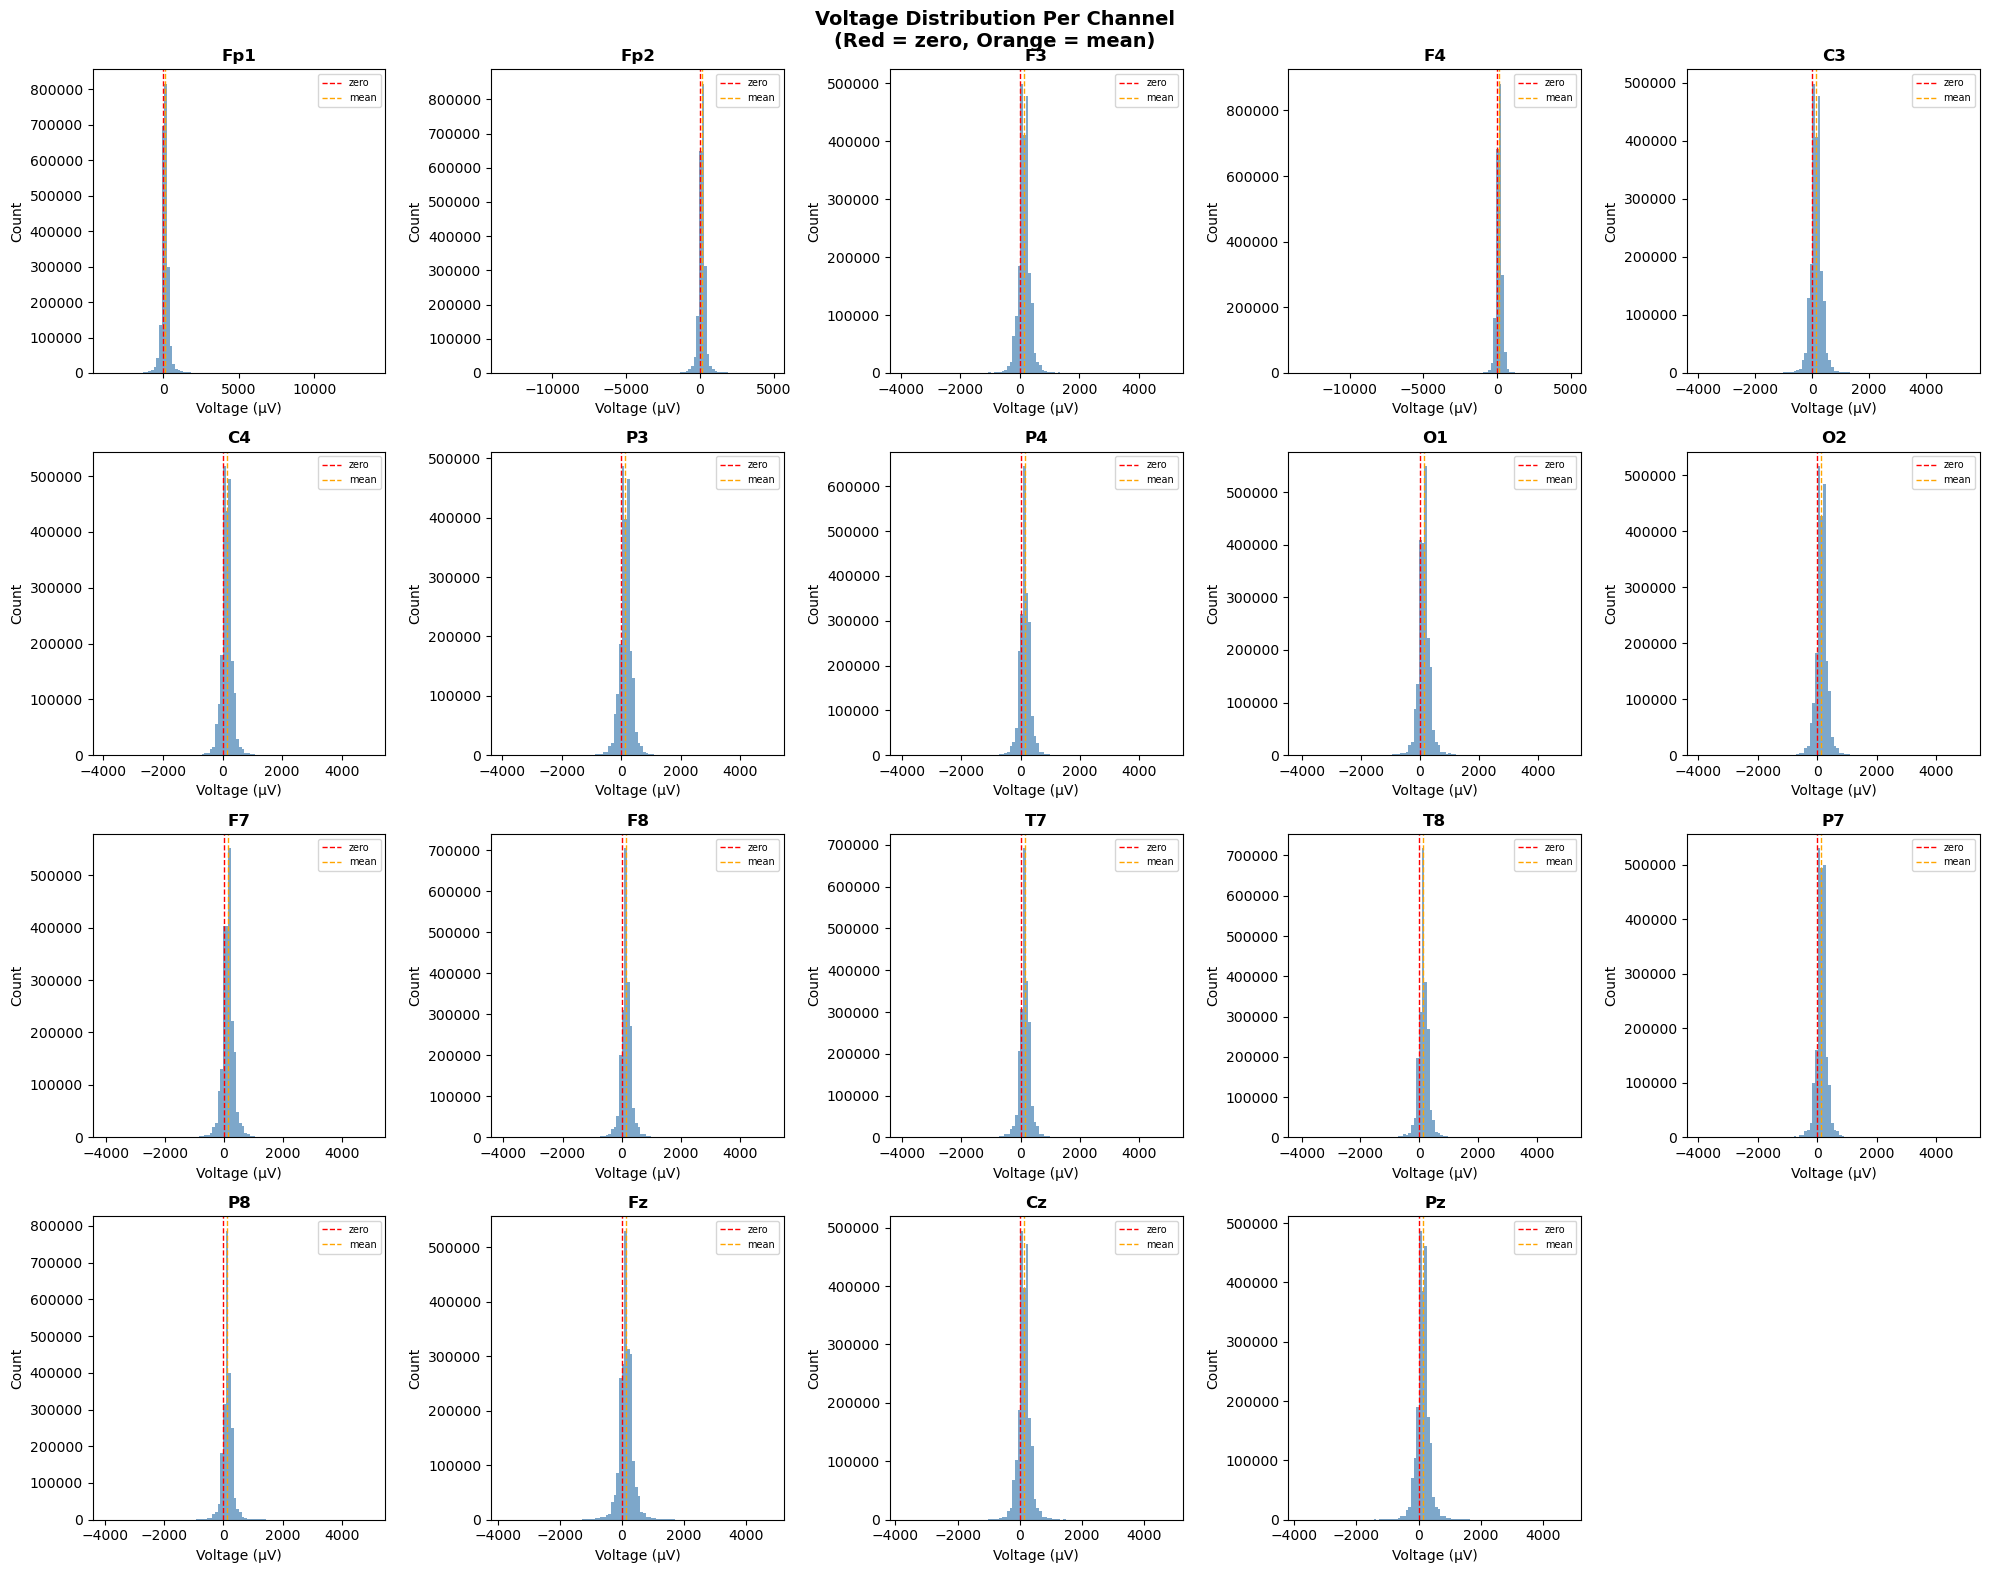

In [47]:
fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

for i, channel in enumerate(eeg_channels):
    axes[i].hist(shuffled_data[channel], bins=100,
                 color='steelblue', alpha=0.7, edgecolor='none')
    axes[i].axvline(x=0, color='red', linestyle='--',
                   linewidth=1, label='zero')
    axes[i].axvline(x=shuffled_data[channel].mean(),
                  color='orange', linestyle='--',
                  linewidth=1, label='mean')
    axes[i].set_title(f'{channel}', fontweight='bold')
    axes[i].set_xlabel('Voltage (µV)')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=7)

# Hide the last empty subplot (19 channels, 20 subplots)
axes[19].set_visible(False)

plt.suptitle('Voltage Distribution Per Channel\n(Red = zero, Orange = mean)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [49]:
# counting how many channels exceed eeg voltage thereshold of ±500 µV
threshold = 500
print('Rows exceeding ±500 µV per channel:')
print('='*45)
total_artefact_rows = set()

for channel in eeg_channels:
    # Find rows here this channel exceeds the threshold in either direction
    mask = (shuffled_data[channel] > threshold)| \
        (shuffled_data[channel] < -threshold)
    count = mask.sum()
    percentage_count = (count/len(shuffled_data)) * 100
    print(f'{channel:5s}: {count:8,} rows ({percentage_count:.3f}%)')

    # collect index of all the artefact rows across all channels
    total_artefact_rows.update(shuffled_data[mask].index.tolist())

print('='*45)
print(f'\nTotal unique rows exceeding ±500 µV')
print(f'in at least one channel: {len(total_artefact_rows):,}')
print(f'That is {len(total_artefact_rows)/len(shuffled_data)*100:.2f}% of all rows')
print(f'\nRows remaining after removal: {len(shuffled_data) - len(total_artefact_rows):,}')

Rows exceeding ±500 µV per channel:
Fp1  :  148,492 rows (6.854%)
Fp2  :  139,846 rows (6.455%)
F3   :   78,483 rows (3.623%)
F4   :   79,984 rows (3.692%)
C3   :   77,289 rows (3.568%)
C4   :   65,358 rows (3.017%)
P3   :   87,573 rows (4.042%)
P4   :   65,674 rows (3.032%)
O1   :   92,267 rows (4.259%)
O2   :   70,485 rows (3.254%)
F7   :  100,318 rows (4.631%)
F8   :   79,823 rows (3.685%)
T7   :   85,205 rows (3.933%)
T8   :   80,827 rows (3.731%)
P7   :   66,264 rows (3.059%)
P8   :   58,539 rows (2.702%)
Fz   :  123,161 rows (5.685%)
Cz   :   83,267 rows (3.844%)
Pz   :   98,805 rows (4.561%)

Total unique rows exceeding ±500 µV
in at least one channel: 550,244
That is 25.40% of all rows

Rows remaining after removal: 1,616,139


In [51]:
# Find all artefact row index
mask_artefact = pd.Series(False, index=shuffled_data.index)
for channel in eeg_channels:
    mask_artefact |= (shuffled_data[channel] > threshold) | \
                    (shuffled_data[channel] < -threshold)

# adding artefact flag to a temporary copy
temp_copy = shuffled_data.copy()
temp_copy['is_artefact'] = mask_artefact

# to check how many rows per participant are flagged
artefact_participant = temp_copy.groupby(['ID', 'Class']).agg(
    rows_total=('is_artefact', 'count'),
    rows_artefact=('is_artefact', 'sum')
).reset_index()

artefact_participant['clean_rows'] = (artefact_participant['rows_total']
                                     -artefact_participant['rows_artefact'])
artefact_participant['percentage_removed'] = (
    artefact_participant['rows_artefact']/
    artefact_participant['rows_total'] * 100
).round(2)
artefact_participant['clean_seconds'] = (
    artefact_participant['clean_rows']/128
).round(1)

# Sort by percentage removed to see worst affected participants
print('Top 10 most affected participants:')
print(artefact_participant.sort_values(
    'percentage_removed', ascending=False).head(10).to_string())
print()
print('Top 10 least affected participants:')
print(artefact_participant.sort_values(
    'percentage_removed', ascending=True).head(10).to_string())
print()
print(f"Participants with less than 30 clean seconds remaining:")
at_risk = artefact_participant[artefact_participant['clean_seconds'] < 30]
print(at_risk[['ID','Class','rows_total',
               'clean_rows','percentage_removed','clean_seconds']].to_string())

Top 10 most affected participants:
       ID    Class  rows_total  rows_artefact  clean_rows  percentage_removed  clean_seconds
79   v303  Control       19222          16998        2224               88.43           17.4
80   v304  Control       13400          10751        2649               80.23           20.7
77   v300  Control       25985          20449        5536               78.70           43.2
118  v60p  Control       12929           9683        3246               74.89           25.4
120   v8p     ADHD       15776          11030        4746               69.92           37.1
2    v109  Control       16044          10666        5378               66.48           42.0
115  v57p  Control       14692           9739        4953               66.29           38.7
81   v305  Control       22273          14467        7806               64.95           61.0
19   v12p     ADHD       17604          10826        6778               61.50           53.0
101  v43p  Control       12750     

Three participants identified at risk of being removed due to excessive artefact contamination exceeding 70%
v303  Control  88.43% removed  →  17.4 seconds remaining
v304  Control  80.23% removed  →  20.7 seconds remaining
v60p  Control  74.89% removed  →  25.4 seconds remaining



In [54]:
# Identify the three participants to exclude entirely
exclude_ids = ['v303', 'v304', 'v60p']

print(f'Excluding {len(exclude_ids)} participants due to')
print(f'excessive artefact contamination (>70%):')
for pid in exclude_ids:
    row = artefact_participant[artefact_participant['ID'] == pid]
    print(f'  {pid}: {row["percentage_removed"].values[0]}% artefacts, '
          f'{row["clean_seconds"].values[0]}s clean remaining')

# Remove excluded participants 
artefact_filtered = shuffled_data[~shuffled_data['ID'].isin(exclude_ids)].copy()

print(f'\nRows before participant exclusion: {len(shuffled_data):,}')
print(f'Rows after participant exclusion:  {len(artefact_filtered):,}')
print(f'Participants remaining: {artefact_filtered["ID"].nunique()}')

Excluding 3 participants due to
excessive artefact contamination (>70%):
  v303: 88.43% artefacts, 17.4s clean remaining
  v304: 80.23% artefacts, 20.7s clean remaining
  v60p: 74.89% artefacts, 25.4s clean remaining

Rows before participant exclusion: 2,166,383
Rows after participant exclusion:  2,120,832
Participants remaining: 118


In [55]:
# Build the artefact mask on the filtered data (118 participants only)
artefact_mask_filtered = pd.Series(False, index=artefact_filtered.index)

for channel in eeg_channels:
    artefact_mask_filtered |= (artefact_filtered[channel] > threshold) | \
                               (artefact_filtered[channel] < -threshold)

# How many rows are flagged in the filtered dataset?
print(f'Artefact rows in 118-participant dataset: '
      f'{artefact_mask_filtered.sum():,}')
print(f'That is '
      f'{artefact_mask_filtered.sum()/len(artefact_filtered)*100:.2f}%'
      f' of remaining rows')

# Remove artefact rows
artefact_clean = artefact_filtered[~artefact_mask_filtered].copy()

# Reset index cleanly
artefact_clean = artefact_clean.reset_index(drop=True)

print(f'\nRows before artefact removal: {len(artefact_filtered):,}')
print(f'Rows after artefact removal:  {len(artefact_clean):,}')
print(f'Rows removed: '
      f'{len(artefact_filtered) - len(artefact_clean):,}')
print(f'\nParticipants retained: {artefact_clean["ID"].nunique()}')
print(f'\nClass distribution after cleaning:')
print(artefact_clean['Class'].value_counts())
print()
print(f'Class percentage after cleaning:')
print((artefact_clean['Class'].value_counts(normalize=True)*100).round(2))

Artefact rows in 118-participant dataset: 512,812
That is 24.18% of remaining rows

Rows before artefact removal: 2,120,832
Rows after artefact removal:  1,608,020
Rows removed: 512,812

Participants retained: 118

Class distribution after cleaning:
Class
ADHD       964466
Control    643554
Name: count, dtype: int64

Class percentage after cleaning:
Class
ADHD       59.98
Control    40.02
Name: proportion, dtype: float64


Clean data summary by class:
         count   mean   std   min   25%    50%    75%    max
Class                                                       
ADHD      61.0  123.5  52.0  37.1  87.9  113.4  141.0  264.4
Control   57.0   88.2  27.7  38.7  72.0   91.4  108.1  146.9

Participants below 30 clean seconds: 0



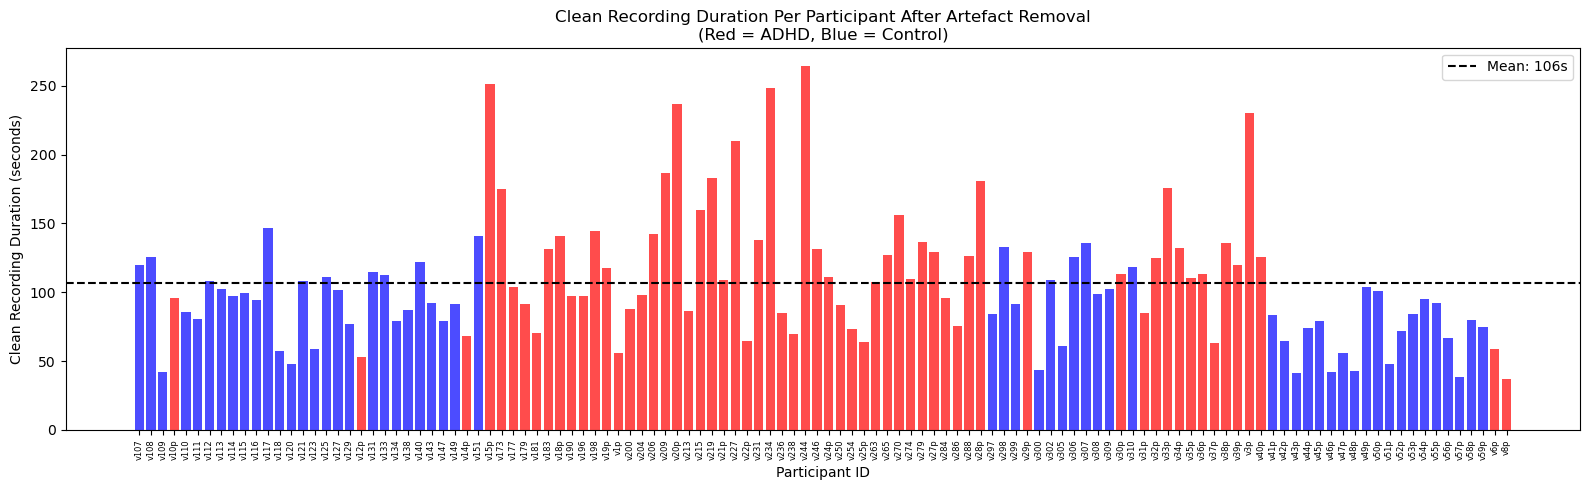

In [56]:
# Check clean data distribution per participant
clean_participant = artefact_clean.groupby(
    ['ID','Class']).size().reset_index(name='clean_rows')
clean_participant['clean_seconds'] = (
    clean_participant['clean_rows']/128).round(1)

# Summary statistics by class
print('Clean data summary by class:')
print(clean_participant.groupby('Class')['clean_seconds'].describe().round(1))
print()

# Any participant now below 30 seconds after cleaning?
below_threshold = clean_participant[
    clean_participant['clean_seconds'] < 30]
print(f'Participants below 30 clean seconds: {len(below_threshold)}')
if len(below_threshold) > 0:
    print(below_threshold.to_string())
print()

# Visualise clean recording duration per participant
plt.figure(figsize=(16,5))
colors = clean_participant['Class'].map(
    {'ADHD':'red','Control':'blue'})
plt.bar(clean_participant['ID'], 
        clean_participant['clean_seconds'],
        color=colors, alpha=0.7)
plt.axhline(y=clean_participant['clean_seconds'].mean(),
            color='black', linestyle='--', linewidth=1.5,
            label=f"Mean: {clean_participant['clean_seconds'].mean():.0f}s")
plt.xticks(rotation=90, fontsize=6)
plt.xlabel('Participant ID')
plt.ylabel('Clean Recording Duration (seconds)')
plt.title('Clean Recording Duration Per Participant After Artefact Removal'
          '\n(Red = ADHD, Blue = Control)')
plt.legend()
plt.tight_layout()
plt.show()

In [67]:
clean_data = artefact_clean.copy()
print(f'Before mean centring: \n{clean_data[eeg_channels].mean().round(2)}')

clean_data[eeg_channels] = clean_data[eeg_channels] - clean_data[eeg_channels].mean()

print(f'After mean centring: \n {clean_data[eeg_channels].mean().round(2)}')

Before mean centring: 
Fp1    113.01
Fp2    115.28
F3     121.50
F4     116.96
C3     121.29
C4     123.34
P3     121.65
P4     123.73
O1     124.85
O2     126.05
F7     121.44
F8     126.24
T7     123.70
T8     125.20
P7     126.01
P8     127.68
Fz     113.09
Cz     116.19
Pz     115.26
dtype: float64
After mean centring: 
 Fp1   -0.0
Fp2    0.0
F3    -0.0
F4    -0.0
C3    -0.0
C4     0.0
P3     0.0
P4     0.0
O1    -0.0
O2     0.0
F7     0.0
F8    -0.0
T7    -0.0
T8     0.0
P7     0.0
P8    -0.0
Fz    -0.0
Cz     0.0
Pz    -0.0
dtype: float64


In [68]:
print('CLEANING SUMMARY')
print(f'Original rows:          {len(shuffled_data):>10,}')
print(f'After participant drop:  {len(artefact_filtered):>10,}')
print(f'After artefact removal:  {len(artefact_clean):>10,}')
print(f'Final clean rows:        {len(clean_data):>10,}')
print()
print(f'Original participants:   {shuffled_data["ID"].nunique():>10}')
print(f'Final participants:      {clean_data["ID"].nunique():>10}')
print(f'Participants excluded:   {"3 (v303, v304, v60p)":>10}')
print()
print(f'Class distribution:')
print(clean_data['Class'].value_counts())
print()
print(f'Voltage range after cleaning:')
print(clean_data[eeg_channels].describe().loc[
    ['mean','std','min','max']].round(2))
print()
print(f'Any missing values: {clean_data.isnull().sum().sum()}')


CLEANING SUMMARY
Original rows:           2,166,383
After participant drop:   2,120,832
After artefact removal:   1,608,020
Final clean rows:         1,608,020

Original participants:          121
Final participants:             118
Participants excluded:   3 (v303, v304, v60p)

Class distribution:
Class
ADHD       964466
Control    643554
Name: count, dtype: int64

Voltage range after cleaning:
         Fp1     Fp2      F3      F4      C3      C4      P3      P4      O1  \
mean   -0.00    0.00   -0.00   -0.00   -0.00    0.00    0.00    0.00   -0.00   
std   152.56  149.31  141.28  138.41  145.05  136.39  149.37  137.60  147.28   
min  -590.01 -592.28 -620.50 -593.96 -620.29 -622.34 -620.65 -622.73 -623.85   
max   359.99  357.72  372.50  356.04  372.71  370.66  372.35  370.27  369.15   

          O2      F7      F8      T7      T8      P7      P8      Fz      Cz  \
mean    0.00    0.00   -0.00   -0.00    0.00    0.00   -0.00   -0.00    0.00   
std   142.19  144.69  127.96  129.48  12

In [70]:
import os

os.makedirs('../data', exist_ok=True)

clean_data.to_csv('../data/clean_data.csv', index=False)

file_size = os.path.getsize('../data/clean_data.csv') / (1024*1024)
print(f'Clean data saved successfully')
print(f'File size: {file_size:.1f} MB')

test_reload = pd.read_csv('../data/clean_data.csv')
print(f'Reload check - rows: {len(test_reload):,}, '
      f'columns: {len(test_reload.columns)}')

Clean data saved successfully
File size: 570.4 MB
Reload check - rows: 1,608,020, columns: 21


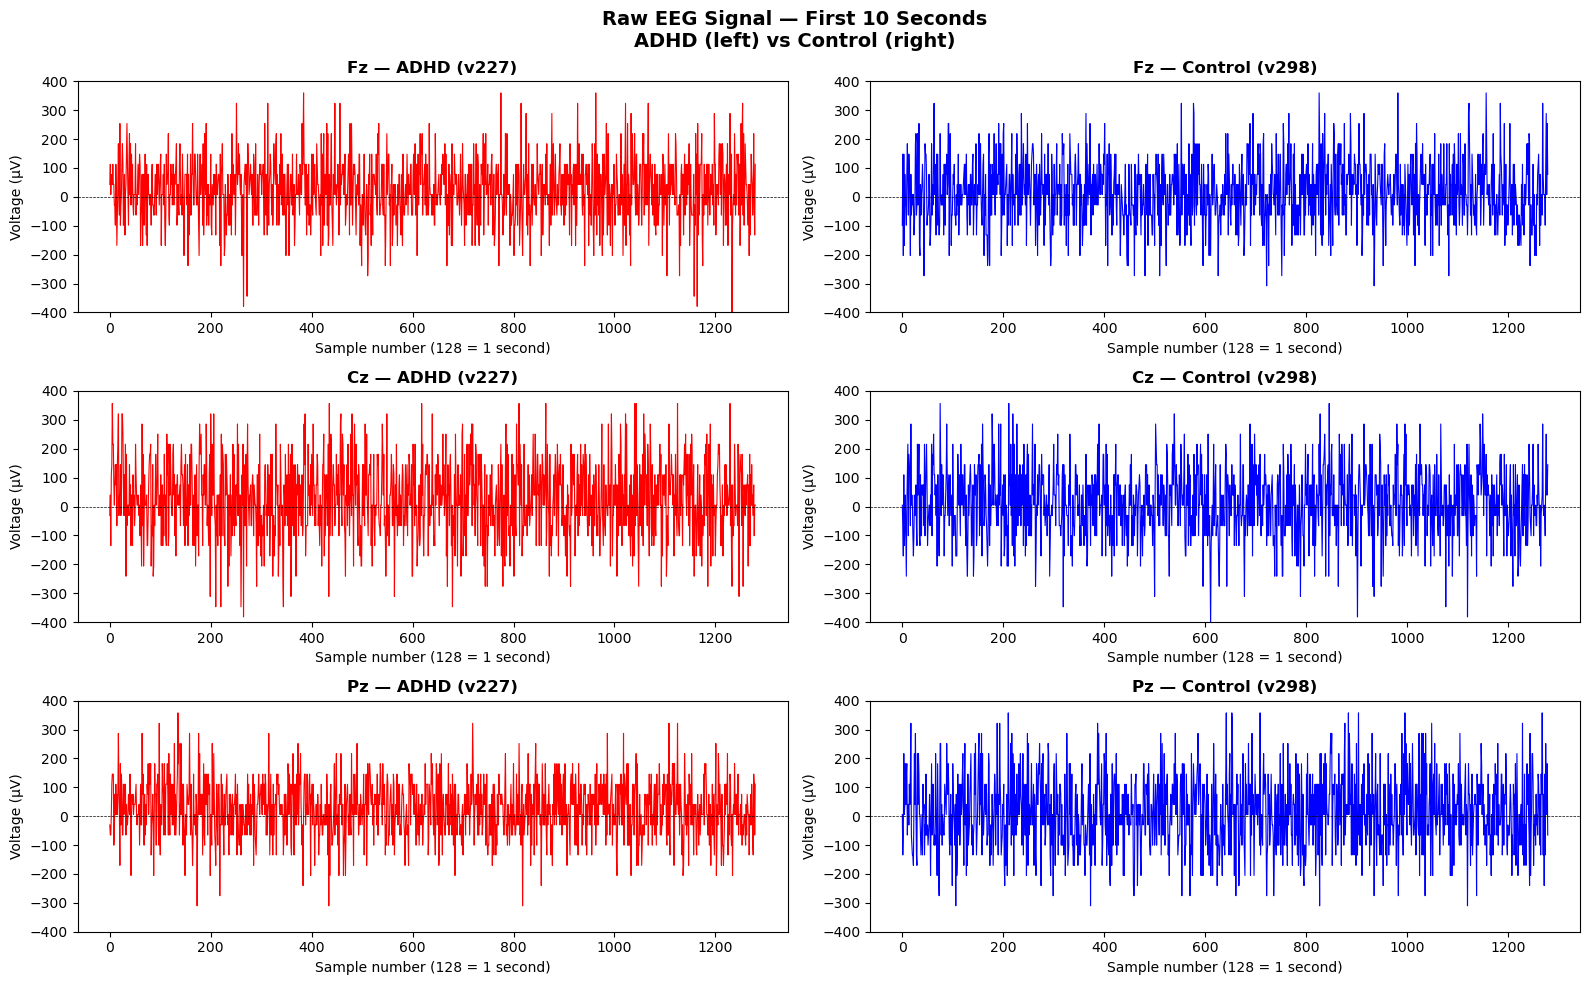

In [71]:
adhd_id = 'v227'      
ctrl_id = 'v298'      

adhd_signal = clean_data[clean_data['ID'] == adhd_id].reset_index(drop=True)
ctrl_signal = clean_data[clean_data['ID'] == ctrl_id].reset_index(drop=True)


window = 1280
channels_to_plot = ['Fz', 'Cz', 'Pz']

fig, axes = plt.subplots(3, 2, figsize=(16, 10))

for i, channel in enumerate(channels_to_plot):
    # ADHD on the left column
    axes[i, 0].plot(
        adhd_signal[channel].values[:window],
        color='red', linewidth=0.8)
    axes[i, 0].set_title(
        f'{channel} — ADHD ({adhd_id})', fontweight='bold')
    axes[i, 0].set_ylabel('Voltage (µV)')
    axes[i, 0].set_xlabel('Sample number (128 = 1 second)')
    axes[i, 0].axhline(y=0, color='black', 
                        linestyle='--', linewidth=0.5)
    axes[i, 0].set_ylim(-400, 400)

    # Control on the right column
    axes[i, 1].plot(
        ctrl_signal[channel].values[:window],
        color='blue', linewidth=0.8)
    axes[i, 1].set_title(
        f'{channel} — Control ({ctrl_id})', fontweight='bold')
    axes[i, 1].set_ylabel('Voltage (µV)')
    axes[i, 1].set_xlabel('Sample number (128 = 1 second)')
    axes[i, 1].axhline(y=0, color='black',
                        linestyle='--', linewidth=0.5)
    axes[i, 1].set_ylim(-400, 400)

plt.suptitle(
    'Raw EEG Signal — First 10 Seconds\n'
    'ADHD (left) vs Control (right)',
    fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

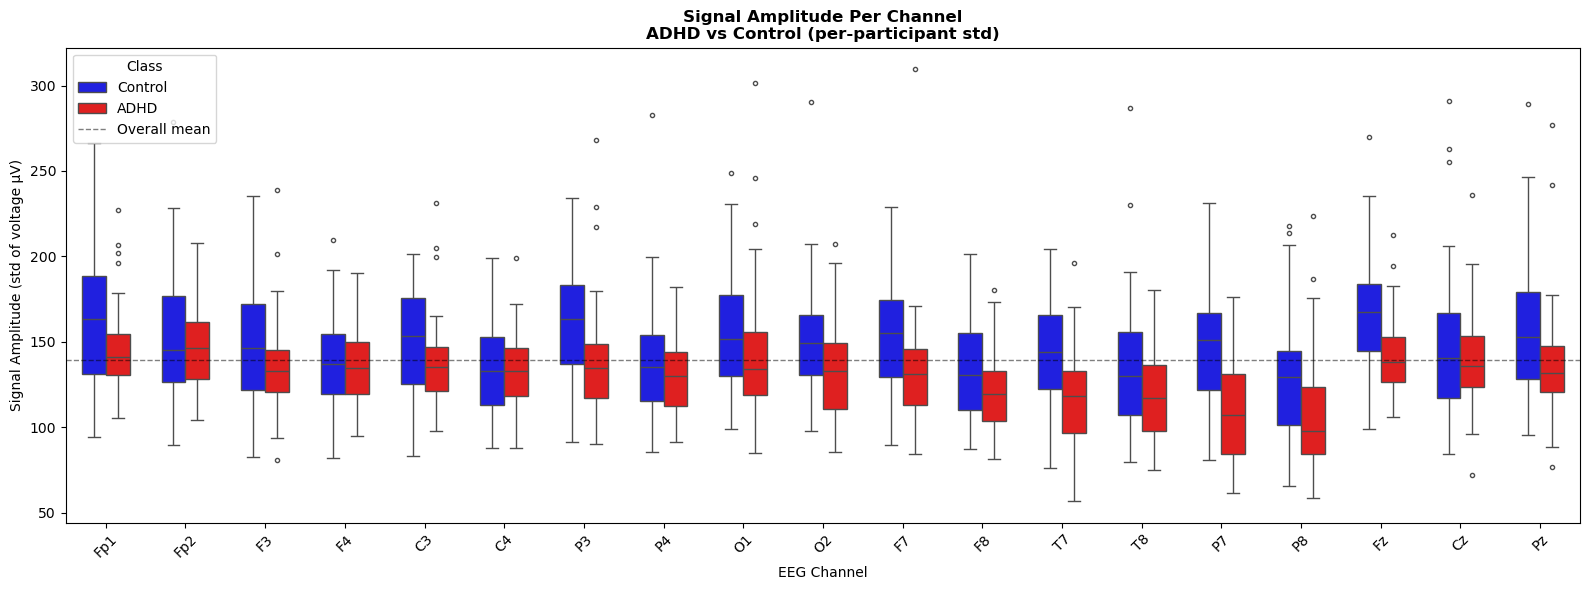

Mean amplitude per channel by class: 
             Fp1     Fp2      F3      F4      C3      C4      P3      P4  \
Class                                                                     
ADHD     144.90  147.44  134.56  136.18  137.90  133.04  138.18  129.42   
Control  163.43  151.56  150.58  137.47  152.56  135.07  161.59  140.47   

             O1      O2      F7      F8      T7      T8      P7      P8  \
Class                                                                     
ADHD     140.81  131.64  132.23  121.85  116.84  117.62  107.26  107.06   
Control  157.43  152.12  154.62  133.75  141.71  134.82  148.56  128.17   

             Fz      Cz      Pz  
Class                            
ADHD     141.06  138.11  135.40  
Control  165.70  147.90  157.54  


In [73]:
import seaborn as sns

# Standard deviation of zero-centred EEG = signal amplitude
participant_std = clean_data.groupby(
    ['ID','Class'])[eeg_channels].std().reset_index()

participant_std_long = participant_std.melt(
    id_vars=['ID','Class'],
    value_vars=eeg_channels,
    var_name='Channel',
    value_name='Amplitude')

plt.figure(figsize=(16, 6))
sns.boxplot(data=participant_std_long,
            x='Channel', y='Amplitude',
            hue='Class',
            palette={'ADHD':'red','Control':'blue'},
            width=0.6, fliersize=3)

plt.axhline(y=participant_std_long['Amplitude'].mean(),
            color='black', linestyle='--',
            linewidth=1, alpha=0.5, label='Overall mean')
plt.xlabel('EEG Channel')
plt.ylabel('Signal Amplitude (std of voltage µV)')
plt.title('Signal Amplitude Per Channel\n'
          'ADHD vs Control (per-participant std)',
          fontweight='bold')
plt.xticks(rotation=45)
plt.legend(title='Class')
plt.tight_layout()
plt.show()

# Print the mean amplitude per class per channel
print(f'Mean amplitude per channel by class: \n {participant_std.groupby('Class')[eeg_channels].mean().round(2)}')

Amplitude difference (Control minus ADHD) per channel:
Positive = Control higher, Negative = ADHD higher
P7     41.30
T7     24.87
Fz     24.64
P3     23.42
F7     22.38
Pz     22.14
P8     21.11
O2     20.48
Fp1    18.53
T8     17.19
O1     16.62
F3     16.02
C3     14.65
F8     11.90
P4     11.05
Cz      9.79
Fp2     4.12
C4      2.03
F4      1.29
dtype: float64



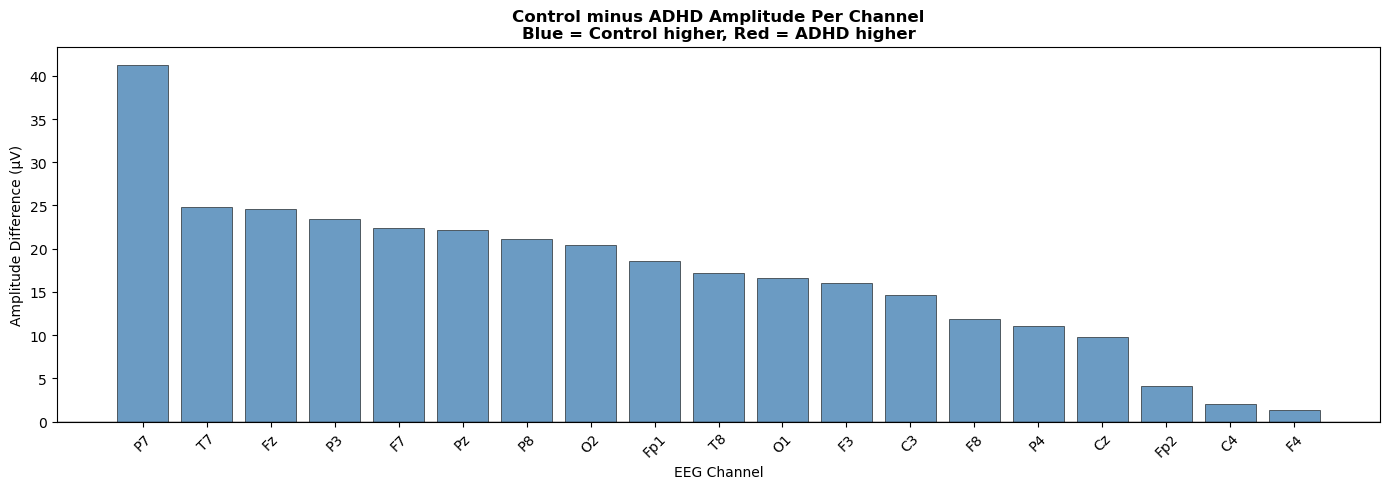

In [74]:

mean_amp = participant_std.groupby('Class')[eeg_channels].mean()

amplitude_diff = (mean_amp.loc['Control'] - 
                  mean_amp.loc['ADHD']).sort_values(ascending=False)

print('Amplitude difference (Control minus ADHD) per channel:')
print('Positive = Control higher, Negative = ADHD higher')
print(amplitude_diff.round(2))
print()

plt.figure(figsize=(14, 5))
colors = ['steelblue' if x > 0 else 'red' 
          for x in amplitude_diff.values]
plt.bar(amplitude_diff.index, amplitude_diff.values,
        color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
plt.axhline(y=0, color='black', linewidth=1)
plt.xlabel('EEG Channel')
plt.ylabel('Amplitude Difference (µV)')
plt.title('Control minus ADHD Amplitude Per Channel\n'
          'Blue = Control higher, Red = ADHD higher',
          fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

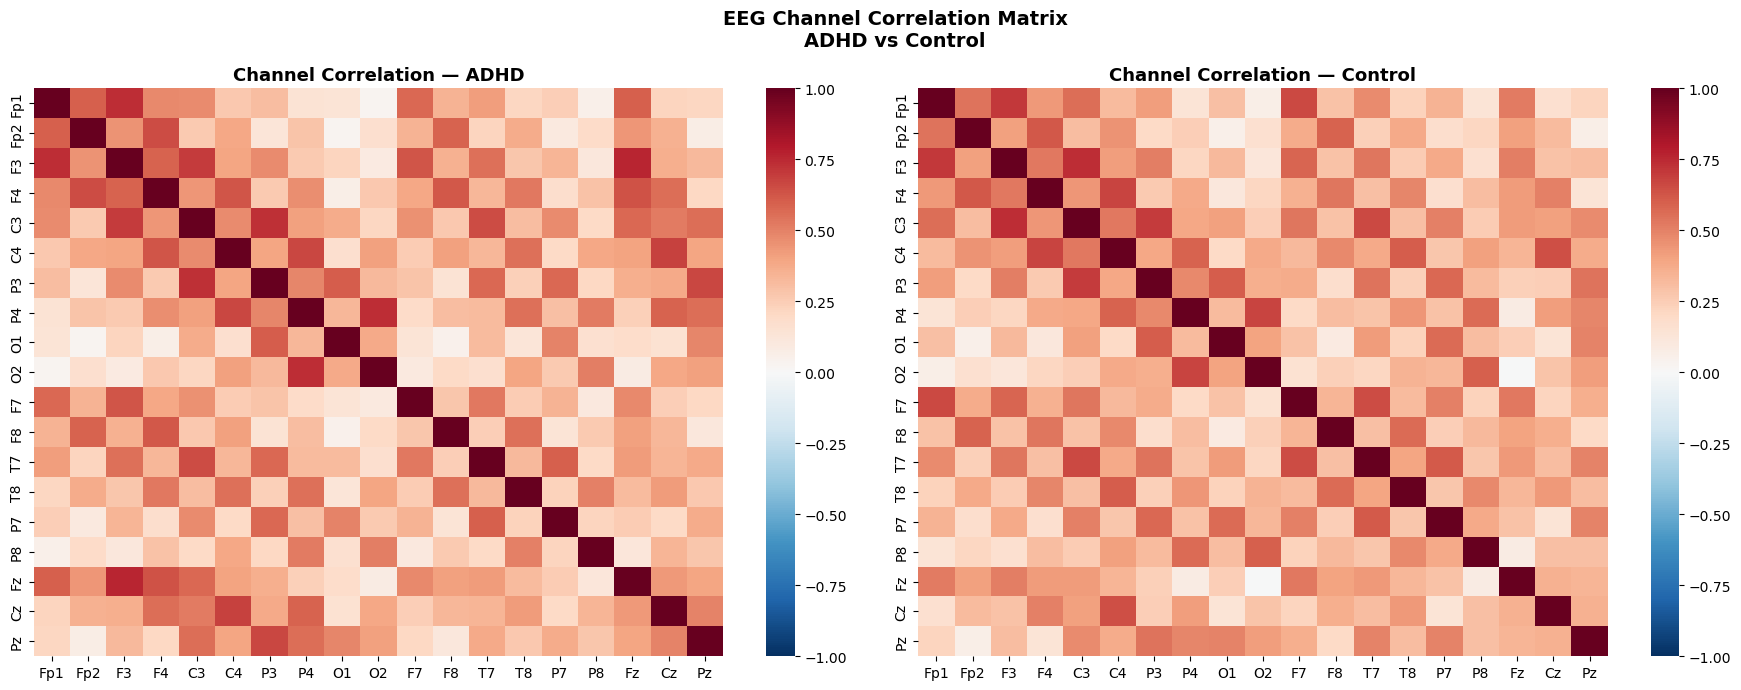

Top 10 channel pairs with biggest correlation difference:
Fz   F3     0.255
F3   Fz     0.255
Fz   F4     0.205
F4   Fz     0.205
P4   Cz     0.172
Cz   P4     0.172
O1   Fp1    0.161
Fp1  O1     0.161
O1   F7     0.160
F7   O1     0.160
dtype: float64


In [75]:
# correlation matrix
sample_data = clean_data.sample(50000, random_state=42)

# Separate by class
adhd_sample = sample_data[sample_data['Class']=='ADHD'][eeg_channels]
ctrl_sample = sample_data[sample_data['Class']=='Control'][eeg_channels]

# Compute correlation matrices
adhd_corr = adhd_sample.corr()
ctrl_corr = ctrl_sample.corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(adhd_corr, annot=False, cmap='RdBu_r',
            vmin=-1, vmax=1, ax=axes[0],
            xticklabels=eeg_channels,
            yticklabels=eeg_channels)
axes[0].set_title('Channel Correlation — ADHD',
                   fontweight='bold', fontsize=13)

sns.heatmap(ctrl_corr, annot=False, cmap='RdBu_r',
            vmin=-1, vmax=1, ax=axes[1],
            xticklabels=eeg_channels,
            yticklabels=eeg_channels)
axes[1].set_title('Channel Correlation — Control',
                   fontweight='bold', fontsize=13)

plt.suptitle('EEG Channel Correlation Matrix\nADHD vs Control',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# the biggest correlation differences between groups
corr_diff = (adhd_corr - ctrl_corr).abs()
corr_diff_unstacked = corr_diff.unstack()
corr_diff_unstacked = corr_diff_unstacked[
    corr_diff_unstacked.index.get_level_values(0) !=
    corr_diff_unstacked.index.get_level_values(1)]

print('Top 10 channel pairs with biggest correlation difference:')
print(corr_diff_unstacked.sort_values(
    ascending=False).head(10).round(3))

# EDA Summary

/
## Dataset Description

| Property | Value |
|---|---|
| Original rows | 2,166,383 |
| Columns | 21 (19 EEG channels + Class + ID) |
| Sampling rate | 128 Hz (1 row = 1 raw time point) |
| Original participants | 121 (61 ADHD, 60 Control) |
| Age range | 7–12 years |
| Task | Visual attention counting task |
| EEG reference | A1/A2 earlobe electrodes |
| Missing values | 0 across all columns |



## Cleaning Pipeline

### Participant Exclusion
Three participants were excluded due to artefact contamination
exceeding 70% of their total recording duration, leaving fewer
than 30 seconds of usable signal after row-level removal.

| ID | Class | Artefact % | Clean seconds remaining |
|---|---|---|---|
| v303 | Control | 88.43% | 17.4s |
| v304 | Control | 80.23% | 20.7s |
| v60p | Control | 74.89% | 25.4s |

**Remaining after exclusion:** 118 participants (61 ADHD, 57 Control)

### Artefact Row Removal
Rows where any channel exceeded ±500 µV were removed.
This threshold is standard in EEG literature and conservatively
targets values that cannot represent physiological brain activity.

- **Rows removed:** 512,812 (24.18% of post-exclusion data)
- Fp1 and Fp2 were most affected (6.8% and 6.5% respectively)
- Artefact rate decreased progressively from frontal to posterior
  channels — the spatial signature of ocular artefacts propagating
  from eye movements across the scalp

### Mean Centring
All 19 channels carried a DC offset of approximately 113–128 µV,
shifting signal means away from the expected zero baseline.
Each channel's mean was subtracted from itself.
All channel means after correction: 0.00 µV.

### Final Clean Dataset

| Property | Value |
|---|---|
| Final rows | 1,608,020 |
| Final participants | 118 (61 ADHD, 57 Control) |
| ADHD rows | 964,466 (60.0%) |
| Control rows | 643,554 (40.0%) |
| Missing values | 0 |
| Saved file | ../data/clean_data.csv (570.4 MB) |


## EDA Findings

### Recording Duration Varies By Class

Recording duration per participant was calculated from row counts
at 128 Hz and compared between diagnostic groups.

| Metric | ADHD | Control |
|---|---|---|
| Mean clean duration | 123.5s | 88.2s |
| Std | 52.0s | 27.7s |
| Minimum | 37.1s | 38.7s |
| Maximum | 264.4s | 146.9s |

- All 5 longest recordings belonged to ADHD participants
- ADHD recordings show greater variability (std=52s vs 27s)
- No participant fell below 30 clean seconds after artefact removal
- The 5 shortest recordings were distributed across both groups

The duration difference is consistent with slower task response
times in ADHD children — recording duration was tied directly
to response speed during the visual counting task. Greater
variability in ADHD recording length also reflects the
heterogeneous nature of the condition.



### Row-Level Class Imbalance

- Pre-cleaning: ADHD 55.7%, Control 44.3%
- Post-cleaning: ADHD 60.0%, Control 40.0%

The imbalance increased after cleaning primarily because
the three excluded participants were all Control, and because
ADHD participants had longer recordings contributing more rows.
The imbalance at participant level remains close to equal
(61 ADHD, 57 Control).



### Control Shows Higher Signal Amplitude Than ADHD

Per-participant signal amplitude was computed as the standard
deviation of voltage values per channel, then compared between
groups. Control participants showed higher amplitude than ADHD
participants across all 19 channels without exception.

Top 5 channels by amplitude difference (Control minus ADHD):

| Channel | Control (µV) | ADHD (µV) | Difference |
|---|---|---|---|
| P7 | 148.6 | 107.3 | 41.3 |
| T7 | 141.7 | 116.8 | 24.9 |
| Fz | 165.7 | 141.1 | 24.6 |
| P3 | 161.6 | 138.2 | 23.4 |
| F7 | 154.6 | 132.2 | 22.4 |

Smallest differences were observed in right frontal channels:
F4 (1.3 µV), C4 (2.0 µV), Fp2 (4.1 µV).

Left hemisphere channels showed consistently larger
Control > ADHD differences than their right hemisphere
equivalents across frontal, temporal, and parietal regions.

This finding is the opposite of what unmedicated ADHD
literature typically reports. All ADHD participants in
this dataset had been taking methylphenidate (Ritalin)
for up to 6 months prior to recording. Methylphenidate
is documented to reduce slow-wave amplitude — this is
the most likely explanation for the reversed pattern.


### ADHD Shows Stronger Inter-Channel Correlation

Pearson correlation matrices were computed on a 50,000-row
random sample separately for each class and compared.

- ADHD shows stronger overall inter-channel correlation
  than Control across the scalp
- Both groups show the expected anatomical block structure —
  neighbouring electrodes correlate more strongly than
  distant ones
- The diagonal blocks correspond to frontopolar, frontal-central,
  parietal-occipital, lateral temporal, and midline electrode groups

Largest absolute correlation differences (ADHD minus Control):

| Channel pair | Difference |
|---|---|
| Fz ↔ F3 | 0.255 |
| Fz ↔ F4 | 0.205 |
| P4 ↔ Cz | 0.172 |
| O1 ↔ Fp1 | 0.161 |
| O1 ↔ F7 | 0.160 |

The strongest differences are between the frontal midline
electrode (Fz) and lateral frontal electrodes (F3, F4),
suggesting reduced functional differentiation within the
frontal lobe in ADHD. Stronger occipital-to-frontal coupling
(O1↔Fp1, O1↔F7) is also observed in ADHD, consistent with
increased frontal involvement during the visual attention task.



## Dataset Characteristics Relevant To Downstream Analysis

The following observations emerged from EDA and are
documented here for reference:

- Each row is a single raw time point at 128 Hz —
  participants contribute between 4,730 and 33,856 clean rows
- The ID column identifies participant membership for
  every row in the dataset
- Recording duration varies substantially across participants
  and correlates with diagnostic group
- Three participants flagged as borderline in terms of
  clean data volume: v8p (37.1s), v57p (38.7s), v12p (53.0s)
- The class imbalance exists at the row level but not
  meaningfully at the participant level
- All amplitude differences between groups are in the
  same direction — this is internally consistent and
  unlikely to be random